# L12: The transient Universe
Let's go back to our previous example on the astrophysical transient.

1. Fit the same model from before with the same priors,  but this time use nested sampling. $y = b$, for $t<t_0$ $y = b + A\\exp[-\alpha(t-t_0)]$, for $t \geq t_0$
Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it). An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.
2. Another possible model that may explain the data is a Gaussian profile described by: $ y = b + A\\exp[-(t-t_0)^2 /2\sigma_W^2 ]$
Fit this model using nested sampling and reasonable priors.
3. Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [7]:
import numpy as np
import dynesty
from matplotlib import pyplot as plt
import emcee
import scipy.stats
import corner
import time
from IPython.display import display, Math, Latex
from dynesty import plotting as dyplot
import warnings

In [8]:
path="/Users/francescarattegni/reps/astrostatistics_bicocca_2025/solutions"
file=path+"/transient.npy"
data=np.load(file)

In [9]:
t = data[:, 0]
flux = data[:, 1]
flux_err = data[:, 2]

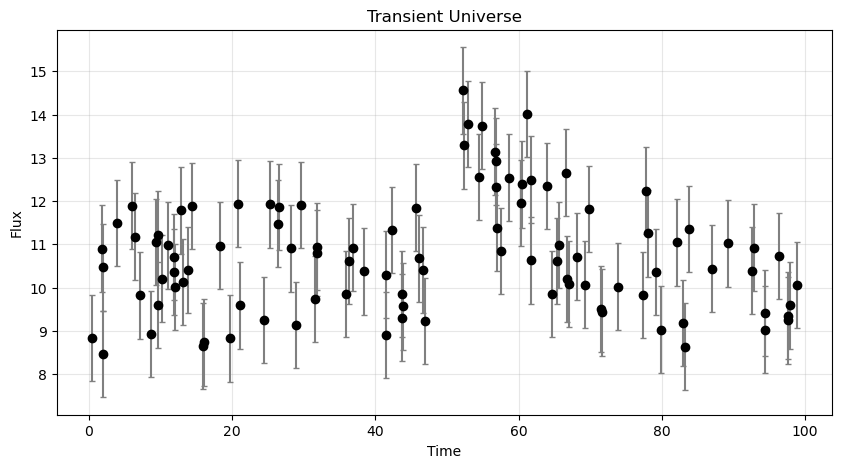

In [10]:
plt.figure(figsize=(10, 5))
plt.errorbar(t, flux, yerr=flux_err, fmt='o', color='black', ecolor='gray', capsize=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Transient Universe')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Parameter limits
A_min, A_max = 0, 50
b_min, b_max = 0, 50
t0_min, t0_max = 0, 100
ln_alpha_min, ln_alpha_max = -5, 5
ln_sigmaW_min, ln_sigmaW_max = -2, 2


# model 1: brust
def model_burst(theta, t):
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)
    y = np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
    return y

# model 2: gaussian
def model_gauss(theta, t):
    b, A, t0, ln_sigma_W = theta
    sigma_W = np.exp(ln_sigma_W)
    return b + A * np.exp(-((t - t0)**2) / (2 * sigma_W**2))

# loglikelihood
def log_likelihood(theta, t, y, yerr, model):

    if model == 'burst':
        y_model = model_burst(theta,t)
    if model == 'gauss':
        y_model = model_gauss(theta,t)
    
    return -0.5 * np.sum(((y - y_model)/yerr)**2 + np.log(2 * np.pi * yerr**2))

# Transformation of our parameter space into a unit hypercube for the nested sampling priors

def ptform(u, model):
    x = np.array(u)
    x[0] = scipy.stats.uniform(loc=b_min,scale=b_max-b_min).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=A_min,scale=A_max-A_min).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0_min,scale=t0_max-t0_min).ppf(u[2])
    
    if model == 'burst':
        x[3] = scipy.stats.uniform(loc=ln_alpha_min,scale=ln_alpha_max-ln_alpha_min).ppf(u[3])
    if model == 'gauss':
        x[3] = scipy.stats.uniform(loc=ln_sigmaW_min,scale=ln_sigmaW_max-ln_sigmaW_min).ppf(u[3])

    return x
   

In [14]:
# Model 1 
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    sampler1 = dynesty.NestedSampler(log_likelihood, ptform, ndim=4, logl_args=[t, flux, flux_err,'burst'],ptform_args=['burst'], nlive=300)
    sampler1.run_nested()
    res1 = sampler1.results
    logZ1, logZ1_err = res1.logz[-1], res1.logzerr[-1]

2331it [00:49,  9.14it/s, bound: 111 | nc: 627 | ncall: 50283 | eff(%):  4.636 | loglstar:   -inf < -178.580 <    inf | logz: -185.220 +/-  0.138 | dlogz: 35.302 >  0.309]/opt/anaconda3/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or di

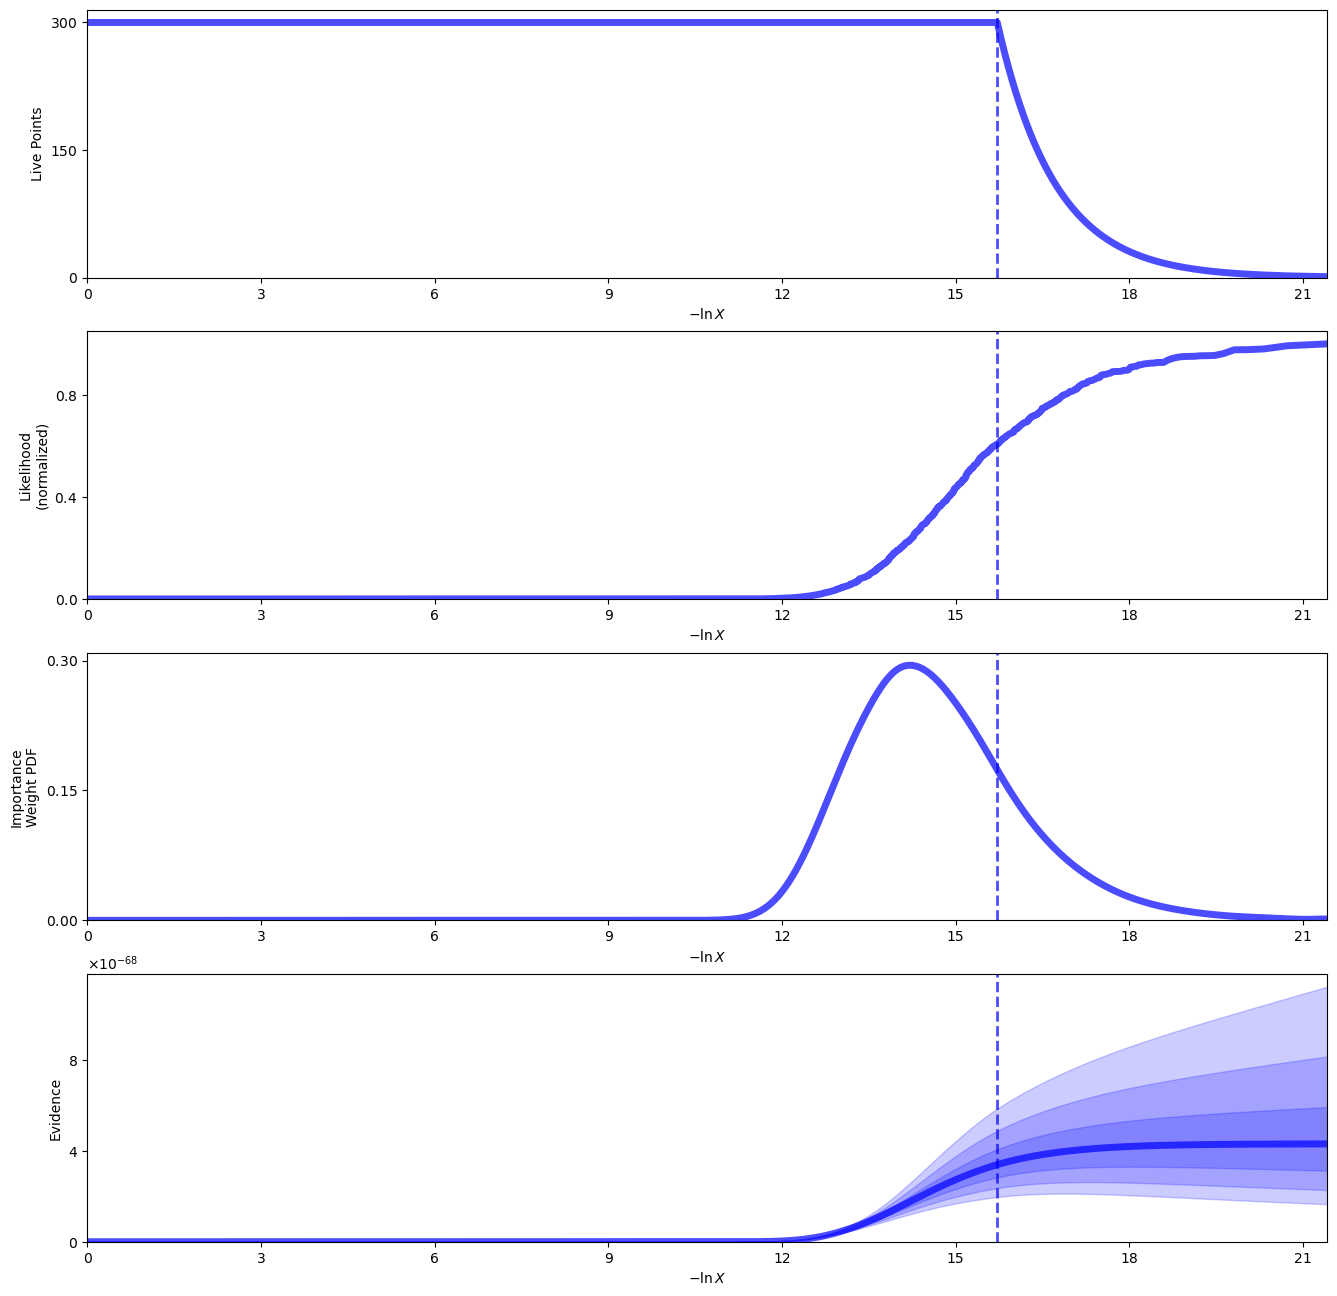

In [15]:
rfig, raxes = dyplot.runplot(res1)

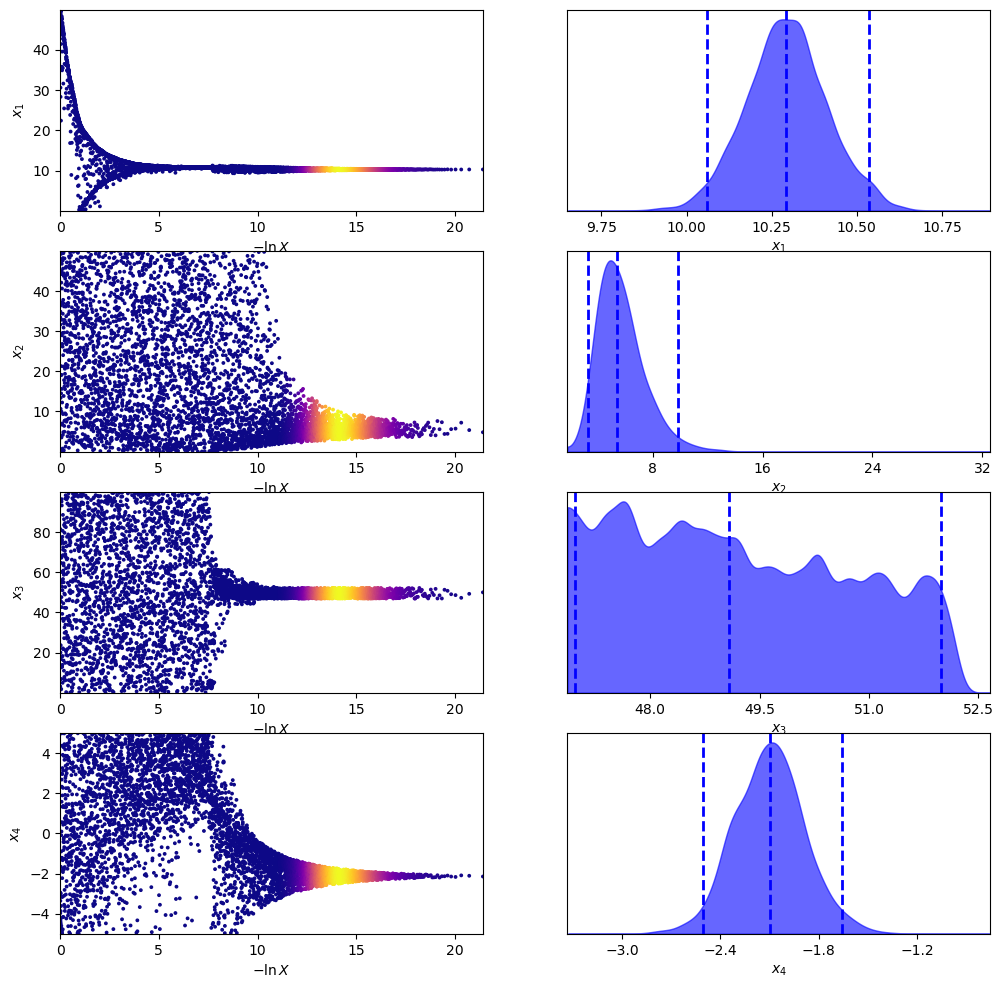

In [16]:
tfig, taxes = dyplot.traceplot(res1)

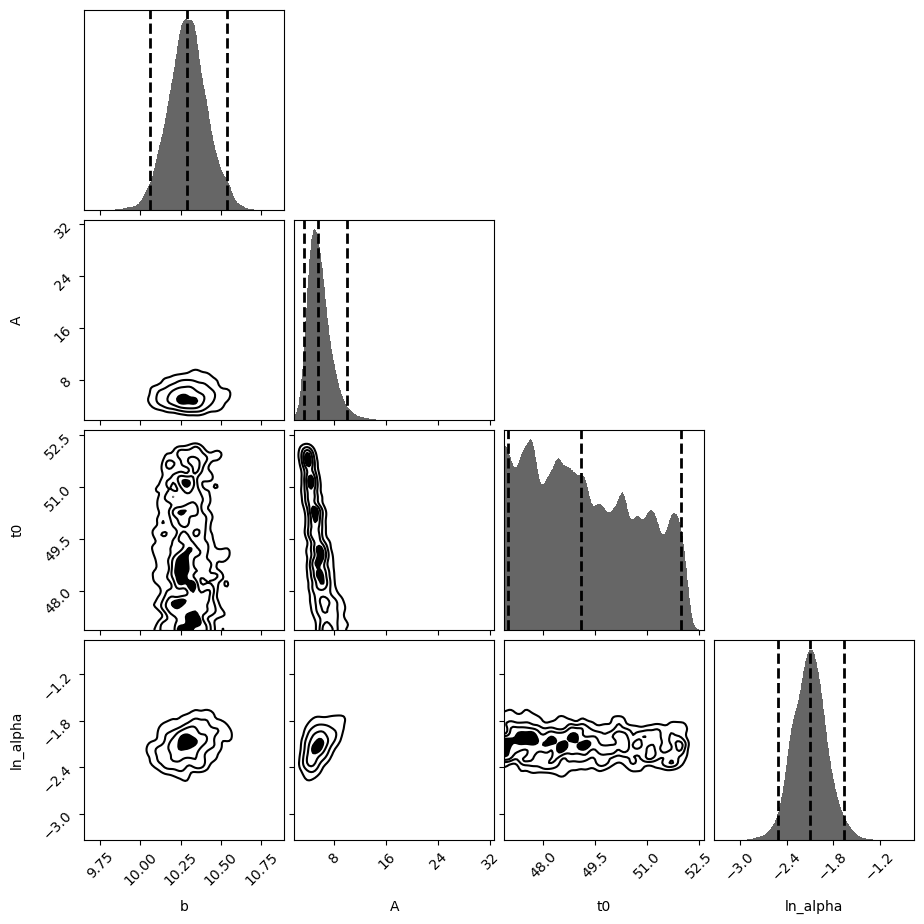

In [17]:
fig, axes = dyplot.cornerplot(res1, labels=["b", "A","t0", "ln_alpha"])
plt.show()

In [18]:
samples1 = res1.samples
weights1 = np.exp(res1.logwt - res1.logz[-1])

def credible_interval(samples, level=0.90):
    """Compute median and symmetric credible interval."""
    lower = (1 - level) / 2
    upper = 1 - lower
    q_low, median, q_high = np.percentile(samples, [100*lower, 50, 100*upper])
    return median, q_high - median, median - q_low

print("PARAMETER ESTIMATES (median with 90% credible intervals)")
param_names_1 = ['b', 'A', 't_0', r'\ln\alpha']
for i, name in enumerate(param_names_1):
    med, plus, minus = credible_interval(samples1[:, i], level=0.90)
    display(Math(f"{name} = {med:.3f}^{{+{plus:.3f}}}_{{-{minus:.3f}}}"))
# Also compute alpha itself (not ln_alpha)
alpha_samples = np.exp(samples1[:, 3])
med_alpha, plus_alpha, minus_alpha = credible_interval(alpha_samples, level=0.90)
display(Math(f"\n \\alpha = {med_alpha:.3f}^{{+{plus_alpha:.3f}}}_{{-{minus_alpha:.3f}}}"))

PARAMETER ESTIMATES (median with 90% credible intervals)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
res1.summary()

Summary
nlive: 300
niter: 4722
ncall: 106319
eff(%):  4.724
logz: -155.115 +/-  0.319


In [20]:
# Model 2 
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    sampler2 = dynesty.NestedSampler(log_likelihood, ptform, ndim=4, logl_args=[t, flux, flux_err,'gauss'],ptform_args=['gauss'], nlive=300)
    sampler2.run_nested()
    res2 = sampler2.results
    logZ2, logZ2_err = res2.logz[-1], res2.logzerr[-1]

2407it [00:50, 12.41it/s, bound: 105 | nc: 487 | ncall: 52232 | eff(%):  4.608 | loglstar:   -inf < -178.836 <    inf | logz: -186.357 +/-  0.150 | dlogz: 31.032 >  0.309]/opt/anaconda3/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2451it [00:57, 18.63it/s, bound: 115 | nc: 29 | ncall: 59747 | eff(%):  4.102 | loglstar:   -inf < -178.183 <    inf | logz: -186.249 +/-  0.150 | dlogz: 30.778 >  0.309]/opt/anaconda3/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are usin

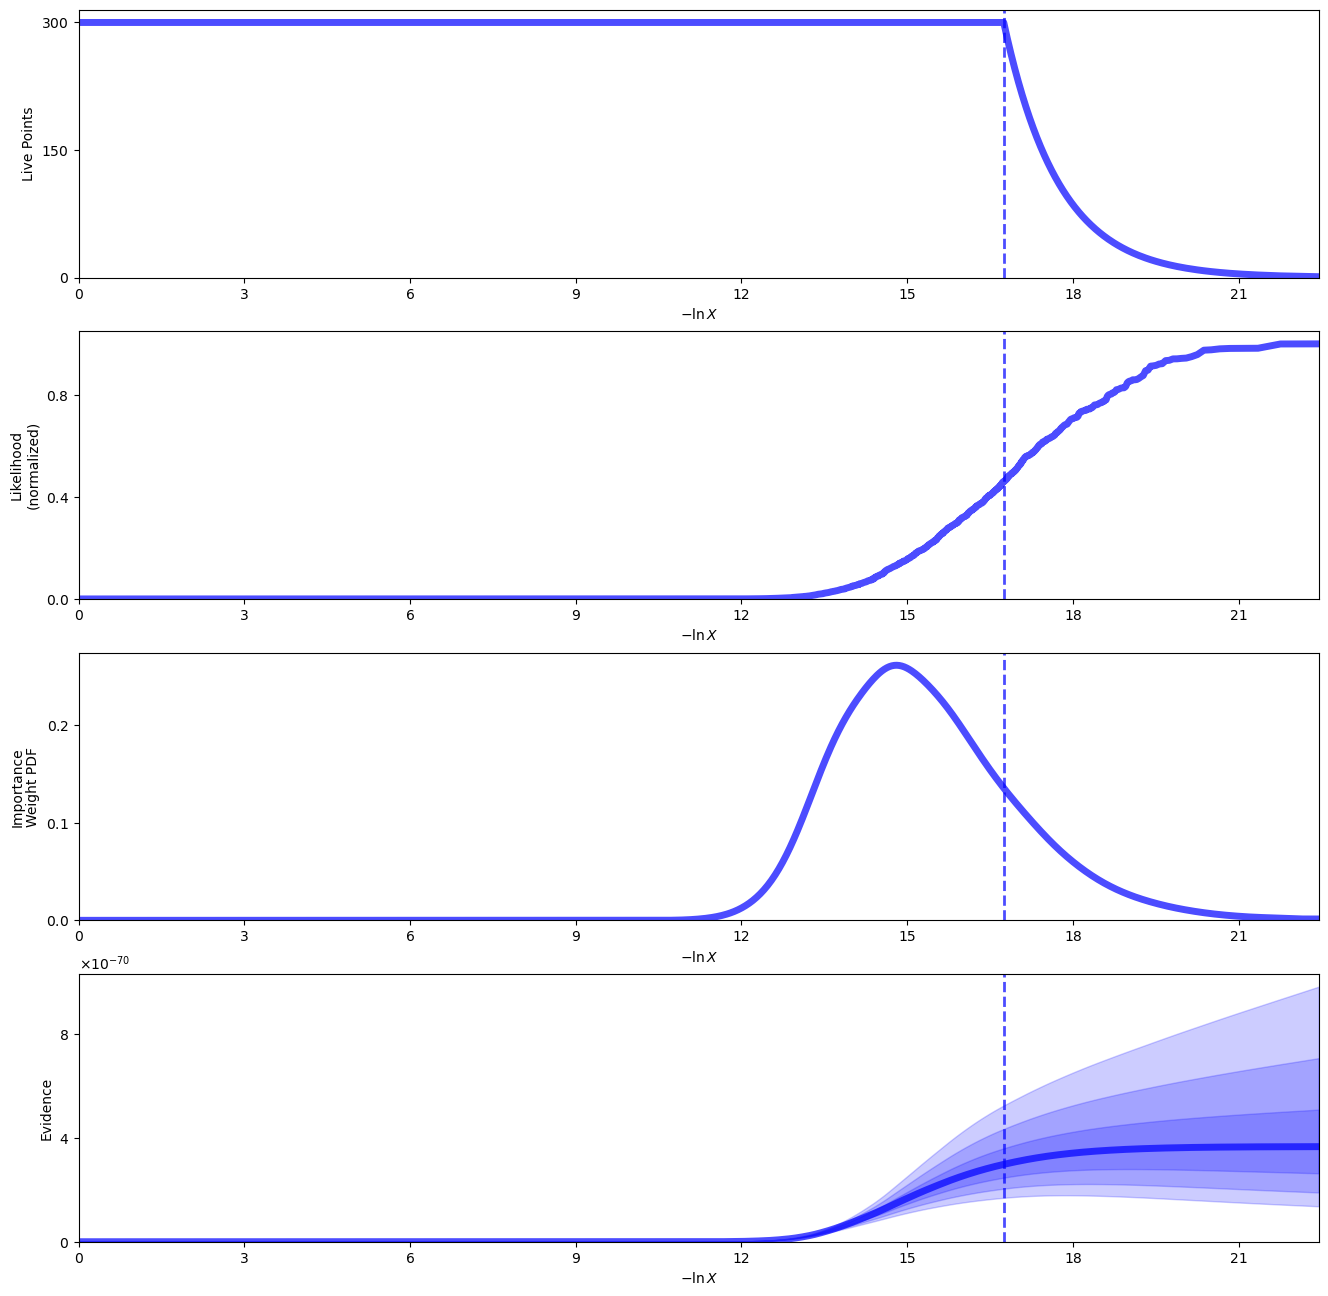

In [21]:
rfig, raxes = dyplot.runplot(res2)

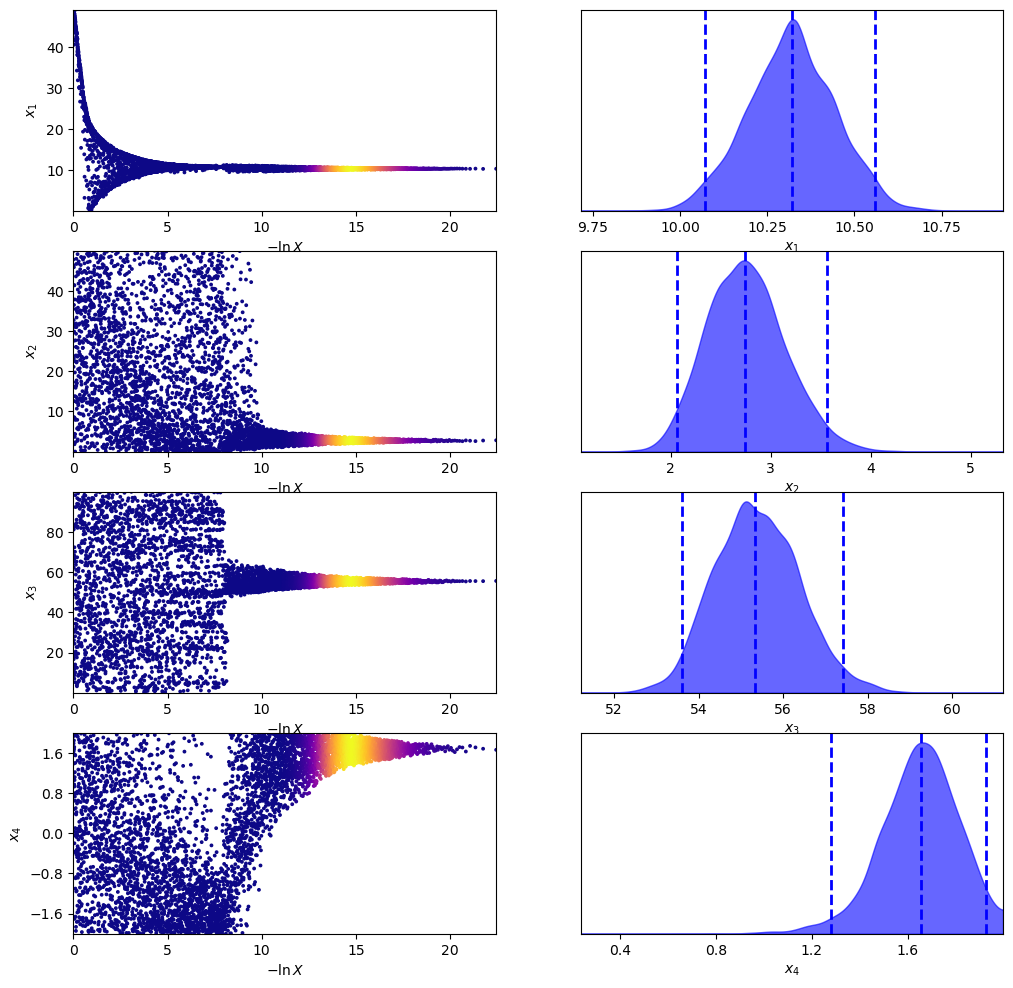

In [22]:
tfig, taxes = dyplot.traceplot(res2)

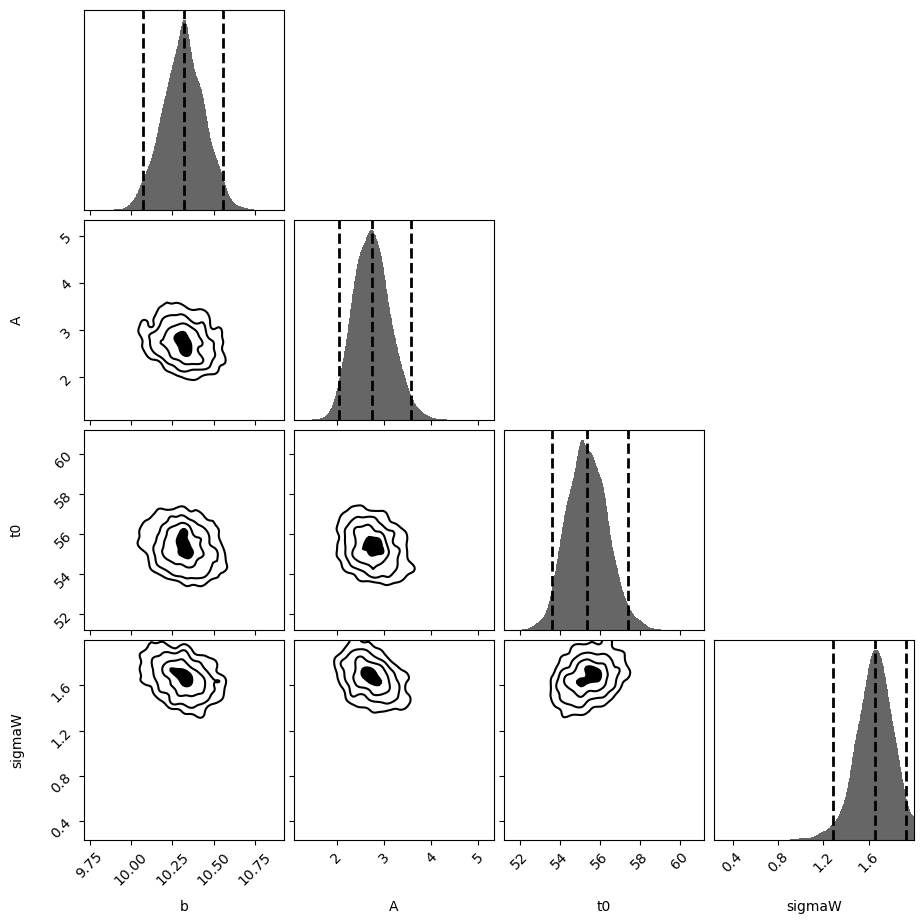

In [23]:
fig, axes = dyplot.cornerplot(res2, labels=["b", "A","t0", "sigmaW"])
plt.show()

In [24]:
samples2 = res2.samples
weights2 = np.exp(res2.logwt - res2.logz[-1])

def credible_interval(samples, level=0.90):
    """Compute median and symmetric credible interval."""
    lower = (1 - level) / 2
    upper = 1 - lower
    q_low, median, q_high = np.percentile(samples, [100*lower, 50, 100*upper])
    return median, q_high - median, median - q_low

print("PARAMETER ESTIMATES (median with 90% credible intervals)")
param_names_2 = ['b', 'A', 't_0', r'\ln\sigma_W']
for i, name in enumerate(param_names_2):
    med, plus, minus = credible_interval(samples2[:, i], level=0.90)
    display(Math(f"{name} = {med:.3f}^{{+{plus:.3f}}}_{{-{minus:.3f}}}"))
# Also compute ln_sigma itself (not ln_alpha)
sigmaW_samples = np.exp(samples2[:, 3])
med_sigmaW, plus_sigmaW, minus_sigmaW = credible_interval(sigmaW_samples, level=0.90)
display(Math(f"\n \\sigma_W = {med_sigmaW:.3f}^{{+{plus_sigmaW:.3f}}}_{{-{minus_sigmaW:.3f}}}"))

PARAMETER ESTIMATES (median with 90% credible intervals)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [25]:
res2.summary()

Summary
nlive: 300
niter: 5032
ncall: 155528
eff(%):  3.428
logz: -159.883 +/-  0.329


In [27]:
print("RISULTATI BAYESIAN EVIDENCE")
print(f"First Model (Burst): ln(Z) = {logZ1:.2f} ± {logZ1_err:.2f}")
print(f"Second Model (Gauss): ln(Z) = {logZ2:.2f} ± {logZ2_err:.2f}")

delta_logZ = logZ1 - logZ2
print(f"\n(ln Z1 - ln Z2): {delta_logZ:.2f}")

abs_delta = abs(delta_logZ)
favored_model = "First Model (Burst)" if delta_logZ > 0 else "Second Model (Gaussian)"

if abs_delta < 1.0:
    interpretation = "Inconclusive"
elif 1.0 <= abs_delta < 2.5:
    interpretation = "Substantial"
elif 2.5 <= abs_delta < 5.0:
    interpretation = "Strong"
else:
    interpretation = "Decisive"

print(f"Favored Model: {favored_model}")
print(f"Strong of Evidence (Jeffreys): {interpretation}")

RISULTATI BAYESIAN EVIDENCE
First Model (Burst): ln(Z) = -155.11 ± 0.32
Second Model (Gauss): ln(Z) = -159.88 ± 0.33

(ln Z1 - ln Z2): 4.77
Favored Model: First Model (Burst)
Strong of Evidence (Jeffreys): Strong
